# MLT Career Prep — Further-Reduced LASSO Model

**Model:** Logistic Regression with L1 (LASSO) penalty 
**Features:** 13 features (applicant + job title + company) 
**Train:** CP 2018–2023 | **Test:** CP 2024 
**Goal:** Predict offer probability, save model for the scoring tool

---

## Cell 1 — Install & Import Libraries

In [1]:
# Run this cell once to install any missing packages
# If already installed, it will just confirm
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'numpy',
                'scikit-learn', 'matplotlib', 'seaborn', 'openpyxl', 'pickle5'], capture_output=True)
print('Libraries ready')

Libraries ready


In [2]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from sklearn.preprocessing  import StandardScaler, OrdinalEncoder
from sklearn.impute         import SimpleImputer
from sklearn.linear_model   import LogisticRegressionCV
from sklearn.metrics        import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully')

All libraries imported successfully


## Cell 2 — File Paths

⚠️ **Only change this cell.** Update the three file paths below to match where your files are saved.

In [3]:
# ── UPDATE THESE THREE PATHS ────────────────────────────────────────
DIAG_FILE    = r'C:/Users/19020/OneDrive/Desktop/MLT CP Anon Data for Diag 12.18.2025 (1) (1).xlsx'
TITLE_FILE   = r'C:/Users/19020/OneDrive/Desktop/title_features.csv'
COMPANY_FILE = r'C:/Users/19020/OneDrive/Desktop/company_attributes_combined.csv'

# Output files — saved to same folder as this notebook
OUTPUT_CSV      = 'lasso_predictions.csv'
MODEL_PKL       = 'lasso_model.pkl'       # saved model for the scoring tool
PREPROCESSOR_PKL= 'lasso_preprocessor.pkl'
METADATA_PKL    = 'lasso_metadata.pkl'

# Model settings
TRAIN_COHORTS = ['CP 2018', 'CP 2020', 'CP 2021', 'CP 2022', 'CP 2023']
TEST_COHORTS  = ['CP 2024']
THRESHOLD     = 0.43
RANDOM_STATE  = 42

print('Configuration ready')
print(f'  Diag file:    {DIAG_FILE}')
print(f'  Title file:   {TITLE_FILE}')
print(f'  Company file: {COMPANY_FILE}')

Configuration ready
  Diag file:    C:/Users/19020/OneDrive/Desktop/MLT CP Anon Data for Diag 12.18.2025 (1) (1).xlsx
  Title file:   C:/Users/19020/OneDrive/Desktop/title_features.csv
  Company file: C:/Users/19020/OneDrive/Desktop/company_attributes_combined.csv


## Cell 3 — Load & Merge All Three Data Files

In [4]:
print('Loading files...')
diag           = pd.read_excel(DIAG_FILE, sheet_name='Data')
title_features = pd.read_csv(TITLE_FILE)
company_attrs  = pd.read_csv(COMPANY_FILE).drop(columns=['Sector'], errors='ignore')

print(f'  Diag:    {diag.shape[0]:,} rows x {diag.shape[1]} columns')
print(f'  Titles:  {title_features.shape[0]:,} rows x {title_features.shape[1]} columns')
print(f'  Company: {company_attrs.shape[0]:,} rows x {company_attrs.shape[1]} columns')

# Merge 1: job title attributes
merged = diag.merge(title_features, on='Title', how='left')
print(f'\nAfter title merge:   {merged.shape[0]:,} rows')

# Merge 2: company attributes
company_attrs = company_attrs.rename(columns={'Company': 'Related Organization'})
merged = merged.merge(company_attrs, on='Related Organization', how='left')
print(f'After company merge: {merged.shape[0]:,} rows')

Loading files...
  Diag:    75,921 rows x 39 columns
  Titles:  13,071 rows x 8 columns
  Company: 201 rows x 13 columns

After title merge:   75,921 rows
After company merge: 75,921 rows


## Cell 4 — Label Target Variable & Filter Rows

In [5]:
POSITIVE = ['Offered','Offered & Committed','Offered & Declined',
            'Offer Rescinded','My offer has been rescinded.']
NEGATIVE = ['Denied','Pending']

merged['label'] = np.nan
merged.loc[merged['Application Status'].isin(POSITIVE), 'label'] = 1
merged.loc[merged['Application Status'].isin(NEGATIVE), 'label'] = 0
labeled = merged[merged['label'].notna()].copy()
labeled['label'] = labeled['label'].astype(int)

# Exclude MLT events and resume drops (these are not real job applications)
cleaned = labeled[(labeled['MLT_Event'] != 1) & (labeled['Resume_Drop'] != 1)].copy()

# Keep only completed cohorts
filtered = cleaned[
    cleaned['Program Enrollment: Program'].isin(TRAIN_COHORTS + TEST_COHORTS)
].copy()

print('Class balance:')
vc = filtered['label'].value_counts()
print(f'  Offered (1): {vc.get(1,0):,}  ({vc.get(1,0)/len(filtered)*100:.1f}%)')
print(f'  Denied  (0): {vc.get(0,0):,}  ({vc.get(0,0)/len(filtered)*100:.1f}%)')
print(f'  Total:       {len(filtered):,}')

Class balance:
  Offered (1): 5,428  (36.7%)
  Denied  (0): 9,355  (63.3%)
  Total:       14,783


## Cell 5 — Define Features (13 total)

All columns excluded and why:
- **Identifiers/admin:** Enrollment ID, Coach, Status
- **Leakage:** Rubric scores (assigned after program), Application Status
- **Dropped in streamlining:** 8 company attributes, 5 title flags
- **Dropped in further reduction:** Carnegie classifications, parental education, demographics, program track, Job_Category (zeroed by LASSO)
- **Excluded by design:** MLT_Event, Resume_Drop (filtered out at row level above)

In [6]:
NON_FEATURE_COLS = [
    'Program Enrollment: Enrollment ID', 'Application Status', 'label',
    'Achievement Orientation #', 'Career Goal # ', 'Work/Internship #',
    'Leadership #', 'Oral Communication #', 'Score out of 5 (CP 18 - 24)',
    'Program Enrollment: Status', 'For CP 2018 - CP 2024, Admissions scores',
    'UG School Data, see Value Lables ', 'Program Enrollment: Coach',
    'Related Organization', 'Primary Major', 'Title', 'HQ_City',
    'Program Enrollment: Program', 'Sector', 'Partner Org?', 'Type',
    'MLT_Event', 'Resume_Drop',
]
STREAMLINE_DROPS = [
    'Public_Private', 'Founded_Year', 'Company_Age_Years', 'Num_Employees',
    'Annual_Revenue_USD_B', 'Market_Cap_USD_B', 'Fortune500_Rank', 'DiversityInc_Top50',
    'Is_Internship', 'Has_Analyst', 'Has_Associate', 'Has_Manager_Director', 'Has_VP_Plus',
]
FURTHER_DROPS = [
    'Bureau of Economic Analysis (BEA) regions (HD2024)',
    'Historically Black College or University (HD2024)',
    'Carnegie Classification 2025: Institutional Classification (HD2024)',
    'Carnegie Classification 2025: Student Access and Earnings (HD2024)',
    'Carnegie Classification 2025: Research Activity Designation (HD2024)',
    'Carnegie Classification 2025: Institutional Size (HD2024)',
    'Carnegie Classification 2025: Award Level Focus (HD2024)',
    'Carnegie Classification 2025: Undergraduate Academic Program Mix (HD2024)',
    "Mother's Education", "Father's Education",
    'Race', 'Ethnicity', 'Gender',
    'Primary Industry Interest',
    'Program Enrollment: Program Track',
    'Job_Category',
]

ALL_DROPS    = NON_FEATURE_COLS + STREAMLINE_DROPS + FURTHER_DROPS
drop_cols    = [c for c in ALL_DROPS if c in filtered.columns]
feature_cols = [c for c in filtered.columns if c not in drop_cols]

numeric_cols = filtered[feature_cols].select_dtypes(include=['float64','int64','bool']).columns.tolist()
cat_cols     = filtered[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f'Total features: {len(feature_cols)}')
print(f'Numeric ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical ({len(cat_cols)}): {cat_cols}')

Total features: 13
Numeric (6): ['Designated Low Income', 'Undergrad GPA', 'Pell Grant Count', 'SAT Score', 'Summer_Internship', 'Title_Word_Count']
Categorical (7): ['Primary Functional Interest', 'First Generation College', 'Position_Type', 'Seniority_Level', 'Industry_Subsector', 'Company_Size_Bucket', 'Is_Fortune500']


## Cell 6 — Train / Test Split

In [7]:
train_df = filtered[filtered['Program Enrollment: Program'].isin(TRAIN_COHORTS)]
test_df  = filtered[filtered['Program Enrollment: Program'].isin(TEST_COHORTS)]

X_train, y_train = train_df[feature_cols], train_df['label'].values
X_test,  y_test  = test_df[feature_cols],  test_df['label'].values

print(f'Train: {len(X_train):,} rows  |  Offer rate: {y_train.mean()*100:.1f}%')
print(f'Test:  {len(X_test):,} rows   |  Offer rate: {y_test.mean()*100:.1f}%')

print('\nTrain cohort breakdown:')
print(train_df.groupby('Program Enrollment: Program')['label']
      .agg(['count','sum','mean'])
      .rename(columns={'count':'Total','sum':'Offers','mean':'Offer Rate'})
      .assign(**{'Offer Rate': lambda x: (x['Offer Rate']*100).round(1).astype(str)+'%'})
)

Train: 10,340 rows  |  Offer rate: 37.6%
Test:  4,443 rows   |  Offer rate: 34.6%

Train cohort breakdown:
                             Total  Offers Offer Rate
Program Enrollment: Program                          
CP 2018                        783     568      72.5%
CP 2020                        837     569      68.0%
CP 2021                       2269     658      29.0%
CP 2022                       2237     927      41.4%
CP 2023                       4214    1168      27.7%


## Cell 7 — Preprocessing Pipeline

In [8]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ('scaler',  StandardScaler()),
    ]), cat_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Processed shape — Train: {X_train_proc.shape}, Test: {X_test_proc.shape}')
print('Preprocessing done')

Processed shape — Train: (10340, 13), Test: (4443, 13)
Preprocessing done


## Cell 8 — Train LASSO Model

**Why LASSO (L1)?** LASSO adds a penalty that forces weak coefficients to exactly zero. This automatically selects the most important features and removes noise. Unlike Ridge (L2) which shrinks all coefficients, LASSO produces a sparse model — cleaner, more interpretable, less prone to overfitting.

**Why LogisticRegressionCV?** It automatically finds the best regularization strength C using 5-fold cross-validation on AUC. No manual tuning needed.

⏱️ *This cell takes 2–4 minutes to run.*

In [9]:
print('Training LASSO model (this takes 2-4 minutes)...')

model = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    Cs=10,
    cv=5,
    class_weight='balanced',
    max_iter=10000,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1,
)
model.fit(X_train_proc, y_train)

n_nonzero = int(np.sum(model.coef_[0] != 0))
print(f'Done!')
print(f'  Best C (regularization): {model.C_[0]:.6f}')
print(f'  Non-zero coefficients:   {n_nonzero} of {len(feature_cols)}')

Training LASSO model (this takes 2-4 minutes)...
Done!
  Best C (regularization): 0.046416
  Non-zero coefficients:   13 of 13


## Cell 9 — Evaluate Model Performance

In [10]:
y_prob = model.predict_proba(X_test_proc)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('='*55)
print('  LASSO MODEL — TEST SET RESULTS (CP 2024)')
print('='*55)
print(f'  AUC-ROC:    {roc_auc_score(y_test, y_prob):.4f}')
print(f'  Accuracy:   {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision:  {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:     {recall_score(y_test, y_pred):.4f}')
print(f'  F1 Score:   {f1_score(y_test, y_pred):.4f}')
print(f'  Threshold:  {THRESHOLD}')
print()
print(f'  Confusion Matrix:')
print(f'                    Predicted Denied  Predicted Offered')
print(f'  Actual Denied          {tn:>5,}              {fp:>5,}')
print(f'  Actual Offered         {fn:>5,}              {tp:>5,}')
print()
null_acc = (y_test == 0).mean()
print(f'  Null model accuracy (predict all denied): {null_acc:.4f}')
print(f'  Our model improvement: +{accuracy_score(y_test, y_pred) - null_acc:.4f}')

  LASSO MODEL — TEST SET RESULTS (CP 2024)
  AUC-ROC:    0.8445
  Accuracy:   0.7925
  Precision:  0.6808
  Recall:     0.7542
  F1 Score:   0.7156
  Threshold:  0.43

  Confusion Matrix:
                    Predicted Denied  Predicted Offered
  Actual Denied          2,361                544
  Actual Offered           378              1,160

  Null model accuracy (predict all denied): 0.6538
  Our model improvement: +0.1386


## Cell 10 — Coefficients (which features matter)

In [11]:
all_feat_names = numeric_cols + cat_cols
coefs = pd.Series(model.coef_[0], index=all_feat_names)
active = coefs[coefs != 0].reindex(
    coefs[coefs != 0].abs().sort_values(ascending=False).index
)
zeroed = coefs[coefs == 0]

print(f'Active coefficients ({len(active)}):')
print(f'  {"Feature":<45}  Coefficient')
print(f'  {"-"*45}  -----------')
for feat, val in active.items():
    direction = '↑ increases offer prob' if val > 0 else '↓ decreases offer prob'
    print(f'  {feat:<45}  {val:+.4f}   {direction}')

if len(zeroed) > 0:
    print(f'\nZeroed out by LASSO ({len(zeroed)}) — no predictive value:')
    for feat in zeroed.index:
        print(f'  {feat}')

Active coefficients (13):
  Feature                                        Coefficient
  ---------------------------------------------  -----------
  Title_Word_Count                               -0.7325   ↓ decreases offer prob
  Company_Size_Bucket                            -0.4714   ↓ decreases offer prob
  Position_Type                                  -0.4202   ↓ decreases offer prob
  Seniority_Level                                +0.2528   ↑ increases offer prob
  Undergrad GPA                                  +0.1542   ↑ increases offer prob
  Summer_Internship                              -0.1515   ↓ decreases offer prob
  SAT Score                                      +0.1483   ↑ increases offer prob
  Primary Functional Interest                    -0.1455   ↓ decreases offer prob
  Pell Grant Count                               -0.1402   ↓ decreases offer prob
  Designated Low Income                          -0.1095   ↓ decreases offer prob
  Is_Fortune500                 

## Cell 11 — Visualizations

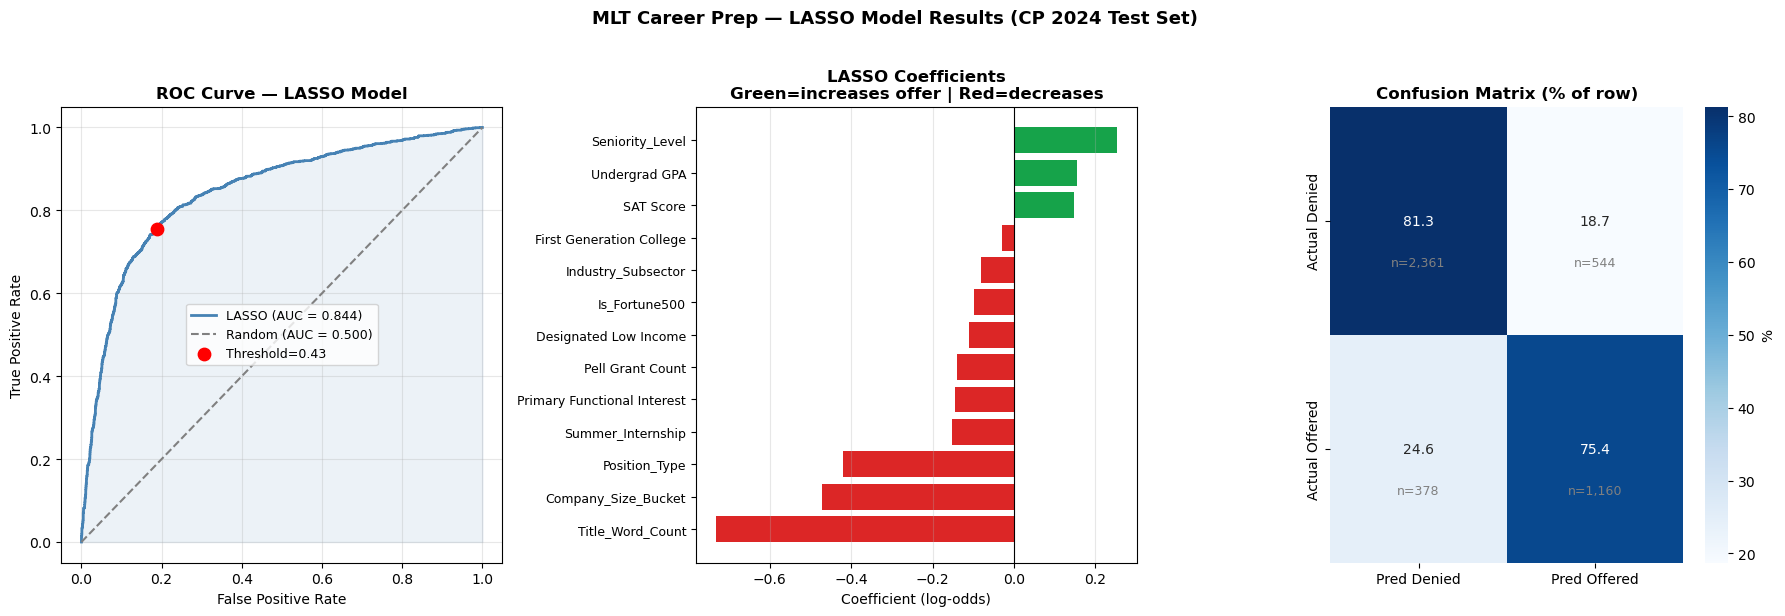

Chart saved: lasso_results.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: ROC Curve ────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'LASSO (AUC = {auc:.3f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].plot([0,1],[0,1],'--', color='gray', label='Random (AUC = 0.500)')
axes[0].scatter([fp/(fp+tn)],[tp/(tp+fn)], color='red', s=80, zorder=5, label=f'Threshold={THRESHOLD}')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — LASSO Model', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# ── Plot 2: Coefficients ─────────────────────────────────────
active_sorted = active.sort_values()
colors = ['#16a34a' if v > 0 else '#dc2626' for v in active_sorted.values]
axes[1].barh(range(len(active_sorted)), active_sorted.values, color=colors)
axes[1].set_yticks(range(len(active_sorted)))
axes[1].set_yticklabels(active_sorted.index, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient (log-odds)')
axes[1].set_title('LASSO Coefficients\nGreen=increases offer | Red=decreases', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# ── Plot 3: Confusion Matrix ─────────────────────────────────
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[2],
            xticklabels=['Pred Denied','Pred Offered'],
            yticklabels=['Actual Denied','Actual Offered'],
            cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        axes[2].text(j+0.5, i+0.7, f'n={cm[i,j]:,}', ha='center', fontsize=9, color='gray')
axes[2].set_title('Confusion Matrix (% of row)', fontweight='bold')

plt.suptitle('MLT Career Prep — LASSO Model Results (CP 2024 Test Set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lasso_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: lasso_results.png')

## Cell 12 — Save Predictions CSV

In [13]:
output = test_df[['Program Enrollment: Enrollment ID']].copy()
output['Predicted_Probability'] = (y_prob * 100).round(2)
output['Predicted_Label']       = y_pred
output['Predicted_Outcome']     = np.where(y_pred == 1, 'Offered', 'Denied')
output['Actual_Label']          = y_test
output['Actual_Outcome']        = np.where(y_test == 1, 'Offered', 'Denied')
output['Correct']               = (y_pred == y_test).astype(int)

output.to_csv(OUTPUT_CSV, index=False)
print(f'Predictions saved: {OUTPUT_CSV}')
print(f'Total rows: {len(output):,}')
print(output.head(10))

Predictions saved: lasso_predictions.csv
Total rows: 4,443
    Program Enrollment: Enrollment ID  Predicted_Probability  Predicted_Label  \
113                          PE-94001                  28.61                0   
117                          PE-94001                  15.91                0   
120                          PE-94001                  35.19                0   
121                          PE-94001                   3.01                0   
124                          PE-94001                   9.57                0   
125                          PE-94001                  46.63                1   
387                          PE-93826                  87.74                1   
388                          PE-93826                  86.57                1   
671                          PE-94440                  13.01                0   
677                          PE-94440                  28.24                0   

    Predicted_Outcome  Actual_Label Actual_Outcom

## Cell 13 — Save Model as Pickle (for the Scoring Tool)

This saves the trained model so you can load it into the scoring tool without retraining every time.

In [14]:
# Save the LASSO model
with open(MODEL_PKL, 'wb') as f:
    pickle.dump(model, f)
print(f'Model saved:        {MODEL_PKL}')

# Save the preprocessor (must use same one at prediction time)
with open(PREPROCESSOR_PKL, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f'Preprocessor saved: {PREPROCESSOR_PKL}')

# Save metadata — feature lists, defaults, threshold
medians  = X_train[numeric_cols].median().to_dict()
modes    = {c: X_train[c].mode()[0] for c in cat_cols}

metadata = {
    'feature_cols':  feature_cols,
    'numeric_cols':  numeric_cols,
    'cat_cols':      cat_cols,
    'threshold':     THRESHOLD,
    'medians':       medians,
    'modes':         modes,
    'model_type':    'LASSO Logistic Regression (L1)',
    'train_cohorts': TRAIN_COHORTS,
    'test_cohorts':  TEST_COHORTS,
    'auc':           round(roc_auc_score(y_test, y_prob), 4),
    'n_features':    len(feature_cols),
    'n_nonzero':     n_nonzero,
}
with open(METADATA_PKL, 'wb') as f:
    pickle.dump(metadata, f)
print(f'Metadata saved:     {METADATA_PKL}')

print()
print('All 3 files needed for the scoring tool:')
print(f'  1. {MODEL_PKL}')
print(f'  2. {PREPROCESSOR_PKL}')
print(f'  3. {METADATA_PKL}')

Model saved:        lasso_model.pkl
Preprocessor saved: lasso_preprocessor.pkl
Metadata saved:     lasso_metadata.pkl

All 3 files needed for the scoring tool:
  1. lasso_model.pkl
  2. lasso_preprocessor.pkl
  3. lasso_metadata.pkl


## Cell 14 — Verify Pickle Works (Load & Test)

Confirms the saved model loads correctly and produces identical predictions.

In [15]:
# Load everything back from disk
with open(MODEL_PKL, 'rb') as f:
    loaded_model = pickle.load(f)
with open(PREPROCESSOR_PKL, 'rb') as f:
    loaded_pre = pickle.load(f)
with open(METADATA_PKL, 'rb') as f:
    loaded_meta = pickle.load(f)

# Re-predict using loaded model
X_verify   = loaded_pre.transform(X_test[loaded_meta['feature_cols']])
probs_verify = loaded_model.predict_proba(X_verify)[:, 1]

# Check predictions are identical
match = np.allclose(probs_verify, y_prob, atol=1e-6)
print(f'Pickle verification: {"PASSED ✓" if match else "FAILED ✗"}')
print(f'  Original AUC:  {roc_auc_score(y_test, y_prob):.4f}')
print(f'  Reloaded AUC:  {roc_auc_score(y_test, probs_verify):.4f}')
print(f'  Max diff:      {np.max(np.abs(probs_verify - y_prob)):.2e}')
print()
print('Loaded metadata:')
for k, v in loaded_meta.items():
    if k not in ['medians','modes','feature_cols','numeric_cols','cat_cols']:
        print(f'  {k}: {v}')

Pickle verification: PASSED ✓
  Original AUC:  0.8445
  Reloaded AUC:  0.8445
  Max diff:      0.00e+00

Loaded metadata:
  threshold: 0.43
  model_type: LASSO Logistic Regression (L1)
  train_cohorts: ['CP 2018', 'CP 2020', 'CP 2021', 'CP 2022', 'CP 2023']
  test_cohorts: ['CP 2024']
  auc: 0.8445
  n_features: 13
  n_nonzero: 13


## Cell 15 — Quick Scoring Demo (single student + multiple jobs)

Shows how the pickle files will be used in the scoring tool.

In [16]:
# Example: score one student across 4 different job scenarios
def score_application(student_profile, job_profile, model, preprocessor, meta):
    row = {}
    # Fill defaults from training medians/modes
    for c in meta['numeric_cols']:
        row[c] = meta['medians'].get(c, 0)
    for c in meta['cat_cols']:
        row[c] = meta['modes'].get(c, '')
    # Override with provided values
    row.update(student_profile)
    row.update(job_profile)
    X = pd.DataFrame([row])[meta['feature_cols']]
    X_proc = preprocessor.transform(X)
    prob = model.predict_proba(X_proc)[0, 1]
    return round(prob * 100, 1)

# Define a student
student = {
    'Undergrad GPA':          3.7,
    'Designated Low Income':  1.0,
    'First Generation College': 'Yes',
    'Pell Grant Count':       1.0,
}

# Score across 4 job scenarios
scenarios = [
    {'label': 'Goldman Sachs — MBA Analyst',     'Seniority_Level': 'MBA / Graduate', 'Title_Word_Count': 2, 'Company_Size_Bucket': 'Enterprise (50K+)', 'Is_Fortune500': 'Yes', 'Industry_Subsector': 'Investment Banking'},
    {'label': 'Mid-size Fintech — Intern',        'Seniority_Level': 'Undergraduate',  'Title_Word_Count': 1, 'Company_Size_Bucket': 'Mid (1K-10K)',       'Is_Fortune500': 'No',  'Industry_Subsector': 'Fintech'},
    {'label': 'Google — Software Engineer Intern','Seniority_Level': 'Undergraduate',  'Title_Word_Count': 3, 'Company_Size_Bucket': 'Enterprise (50K+)', 'Is_Fortune500': 'Yes', 'Industry_Subsector': 'Technology'},
    {'label': 'Nonprofit — Program Manager',      'Seniority_Level': 'Unspecified',    'Title_Word_Count': 2, 'Company_Size_Bucket': 'Small (<1K)',        'Is_Fortune500': 'No',  'Industry_Subsector': 'Nonprofit'},
]

print('DEMO — Job Fit Scoring for One Student')
print(f'Student: GPA {student["Undergrad GPA"]}, Low Income, First Gen')
print('-'*55)

results = []
for sc in scenarios:
    lbl = sc.pop('label')
    prob = score_application(student, sc, loaded_model, loaded_pre, loaded_meta)
    fit = '🟢 Strong' if prob >= 65 else ('🟡 Moderate' if prob >= 40 else '🔴 Reach')
    results.append((prob, lbl, fit))

for prob, lbl, fit in sorted(results, reverse=True):
    print(f'  {fit:<14}  {prob:>5.1f}%   {lbl}')

DEMO — Job Fit Scoring for One Student
Student: GPA 3.7, Low Income, First Gen
-------------------------------------------------------
  🟡 Moderate       44.1%   Google — Software Engineer Intern
  🔴 Reach          36.8%   Mid-size Fintech — Intern
  🔴 Reach          32.7%   Nonprofit — Program Manager
  🔴 Reach          14.4%   Goldman Sachs — MBA Analyst


---
## Summary

You now have:
- ✅ Trained LASSO model with 13 features
- ✅ Performance metrics on CP 2024 test set
- ✅ Coefficients showing what drives offer probability
- ✅ `lasso_model.pkl` — saved model
- ✅ `lasso_preprocessor.pkl` — saved preprocessor  
- ✅ `lasso_metadata.pkl` — feature lists, defaults, threshold
- ✅ `lasso_predictions.csv` — all CP 2024 predictions
- ✅ `lasso_results.png` — charts

To use in the scoring tool, copy the 3 `.pkl` files into the `mlt_app` folder.